Import modules 

In [2]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px # for interactive plots
import plotly.graph_objects as go #for more complex interactive plots
from collections import defaultdict #for the KNN imputation function
from tabulate import tabulate #for pretty printing tables

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram
import folium #for interactive maps

Define data overview function and potential others to see if imputation works etc

In [3]:
def summarize_dataframe(df):
    """
    Prints a summary of the DataFrame's columns including:
    - dtype
    - count of non-null values
    - % completeness
    - number of unique values
    Output is printed in GitHub-style markdown table.
    """
    def summarize_column(col_data):
        numeric_data = pd.to_numeric(col_data, errors='coerce')
        is_numeric = numeric_data.notna().sum() > 0
        return {
            "dtype": col_data.dtype,
            "count": col_data.notna().sum(),
            "pct_complete": round(col_data.notna().mean() * 100, 1),
            "n_unique": col_data.nunique(dropna=True)
        }

    summary_long = (
        pd.DataFrame([
            {"variable": col, **summarize_column(df[col])}
            for col in df.columns
        ])
        .sort_values(by="pct_complete", ascending=False)
        .reset_index(drop=True)
    )

    print(tabulate(summary_long, headers="keys", tablefmt="github", showindex=False))

Load in the dataset 

In [15]:
print("Current working directory:", os.getcwd())
df = pd.read_csv("../../../data/finaldatasets/testdata/RFgdpadded25-7.csv")

print(list(df.columns))

df = df[df["Grain.yield..tons.ha.1."] <= 30]

df = df[(df["Observation.period"] >= 2005) & (df["Observation.period"] <= 2020)]


# df.to_csv("../../../data/finaldatasets/testdata/RFgdpadded12-7.csv", index=False)

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering
['Unnamed: 0.1', 'Unnamed: 0', 'id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soi

/tmp/ipykernel_86715/2856660321.py:2: DtypeWarning: Columns (8,9,15,16,17,18,19,22,24,25,31,33,35,36,37,38,39,46,47,72,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/finaldatasets/testdata/RFgdpadded25-7.csv")


In [16]:
summarize_dataframe(df)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Unnamed: 0.1                                          | int64   |   69430 |          100   |      69430 |
| temp8                                                 | float64 |   69430 |          100   |        282 |
| Unnamed: 0                                            | int64   |   69430 |          100   |      69430 |
| AEZ                                                   | float64 |   69430 |          100   |         31 |
| Elevation                                             | int64   |   69430 |          100   |        196 |
| temp1                                                 | float64 |   69430 |          100   |        268 |
| temp2                                                 | float64 |   69430 |          100   |        270 |
| temp3                     

In [8]:
df["Wheat.Type"].unique()

def clean_wheat_types(df, column_name):
    """Clean and categorize wheat types"""
    df = df.copy()

    def categorize_wheat(wheat_type):
        # Keep NaN as NaN
        if pd.isna(wheat_type):
            return np.nan

        wheat_str = str(wheat_type).lower().replace('Â\xa0L.', '').replace('â', '').replace(')','').replace('Desf.','')

        if 'aestivum' in wheat_str:
            return 'Common_wheat'
        elif 'durum' in wheat_str or 'turgidum' in wheat_str:
            return 'Durum_wheat'
        else:
            return 'Other'

    df['Wheat.Type'] = df[column_name].apply(categorize_wheat)
    return df

# Example usage: overwrite the Wheat.Type column with cleaned/categorized values
df = clean_wheat_types(df, "Wheat.Type")

In [14]:
df["Wheat.Type"].unique()

array([nan, 'Common_wheat', 'Durum_wheat'], dtype=object)

In [10]:
df.to_csv("../../../data/finaldatasets/testdata/RFgdpadded25-7.csv")

#### Below is code for saving temporal and regional ranges for model comparisons

In [17]:
#Format columns for producing a tree
df.columns = df.columns.str.replace(' ', '_')

In [18]:
# Replace blank or empty cells with np.nan
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

#make sure all columns have nan so xgboost can handle it
(df == ' ').sum().sum()

0

In [19]:

#Check data
print("Yield min/max:", df["Grain.yield..tons.ha.1."].min(), "/", df["Grain.yield..tons.ha.1."].max())

# Check if the sum of yield is greater than 30
print((df["Grain.yield..tons.ha.1."] > 30).sum())

Yield min/max: 0.01673634 / 28.5
0


In [20]:
#for potential future use, if we want to filter by country

# Filter only North America values
# north_america_countries = ["Mexico", "United States of America", "Canada"]
# df = df[df["Country"].isin(north_america_countries)]

# Define bounding box coordinates
lat_min, lat_max = 0.0, 90.0
lon_min, lon_max = -180.0, 180.0

# Create a potential filter for global data 
df_europe_north = df[
    (df['Conversion.for.latitude'] >= lat_min) &
    (df['Conversion.for.latitude'] <= lat_max) &
    (df['Conversion.for.longitude'] >= lon_min) &
    (df['Conversion.for.longitude'] <= lon_max)
]


In [21]:
# map_center = [df_europe_north['Conversion.for.latitude'].mean(), df_europe_north['Conversion.for.longitude'].mean()]
# m = folium.Map(location=map_center, zoom_start=4)

# # Plot filtered points
# for _, row in df_europe_north.iterrows():
#     folium.CircleMarker(
#         location=[row['Conversion.for.latitude'], row['Conversion.for.longitude']],
#         radius=3,
#         fill=True,
#         color='blue',
#         fill_opacity=0.7
#     ).add_to(m)

# # Draw the bounding box on the map for reference
# folium.Rectangle(
#     bounds=[[lat_min, lon_min], [lat_max, lon_max]],
#     color='red',
#     fill=False,
#     weight=2
# ).add_to(m)

# m

In [22]:
df.to_csv("../../../data/finaldatasets/testdata/Treedata1.csv", index=False)

In [23]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../data/finaldatasets/testdata/Treedata1.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering
['Unnamed:_0.1', 'Unnamed:_0', 'id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soi

/tmp/ipykernel_86715/1461399592.py:4: DtypeWarning: Columns (8,9,15,16,17,18,19,22,24,25,31,33,35,36,37,38,39,46,47,72,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../data/finaldatasets/testdata/Treedata1.csv")  # for variogram, etc.


#### Below is code for imputation that occured for RF/other multivariate statistical approaches

There were features in the dataset that had to be dropped for their incompleteness for utilisation in RF or multivariate statistical approaches that do not tolerate missingness, as either features were simply too incomplete or imputation approaches considered were simply too unreliable given domain knowledge. The decision to use these features going foward in the final model also reflected the inability for stakeholders to obtain these data at scale. This choice was further reaffirmed by cliatic variables explaining most of yield variability in tree based models

In [24]:
# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = []

# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set( HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (69430, 98)
Shape after dropping: (69430, 81)
Dropped columns: ['Planting.date.1', 'harvest_date_clean', 'Treatment.type', 'harvest_week', 'harvest_month', 'rainfed_end_date', 'Planting_Month', 'Emissions..yes.no.', 'Harvesting.date.1', 'Planting.date', 'Planting_Week', 'Irrigation..mm.', 'irr_end_date', 'Agricultural_Use_–_Rodenticides_(t)', 'Agricultural_Use_–_Other_Pesticides_nes_(t)', 'Pest.severity.score.......66', 'end_date']
Remaining columns: ['Unnamed:_0.1', 'Unnamed:_0', 'id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.

In [25]:
df_cleaned.to_csv("../../../data/finaldatasets/testdata/XGBoost.csv", index=False)

Find columns to impute with spacially aware KNNs

continous features

Explore feature distribution for imputation 

In [80]:

# import plotly.graph_objects as go
# import pandas as pd

# # Features to toggle
# features = [
#     "N.rate..kg.N.ha.1.",
#     "Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha)",
#     "Agricultural_Use_–_Insecticides_(t)",
#     "Agricultural_Use_–_Herbicides_(t)",
#     "Agricultural_Use_–_Fungicides_and_Bactericides_(t)"
# ]

# # Clean and rename for plotting
# df_plot = df_raw.dropna(
#     subset=features + ['Conversion.for.latitude', 'Conversion.for.longitude', 'year']
# ).rename(columns={
#     'Conversion.for.latitude': 'lat',
#     'Conversion.for.longitude': 'lon',
#     'year': 'Year'
# })

# # Create figure
# fig = go.Figure()

# # Add a trace for each feature
# for i, feature in enumerate(features):
#     visible = True if i == 0 else False  # Only first trace visible by default
#     fig.add_trace(go.Scattergeo(
#         lon=df_plot['lon'],
#         lat=df_plot['lat'],
#         text=df_plot['Year'].astype(str),
#         marker=dict(
#             color=df_plot[feature],
#             colorscale='Viridis',
#             colorbar=dict(title=feature) if visible else None,
#             cmin=df_plot[feature].min(),
#             cmax=df_plot[feature].max(),
#             size=5
#         ),
#         name=feature,
#         visible=visible
#     ))

# # Create dropdown
# buttons = []
# for i, feature in enumerate(features):
#     visibility = [j == i for j in range(len(features))]
#     buttons.append(dict(
#         label=feature,
#         method="update",
#         args=[{"visible": visibility},
#               {"title": f"Spatial Distribution of {feature}"}]
#     ))

# fig.update_layout(
#     title="Spatial Distribution",
#     geo=dict(showland=True, landcolor="lightgray", showcountries=True),
#     updatemenus=[{
#         "buttons": buttons,
#         "direction": "down",
#         "showactive": True,
#         "x": 0.1,
#         "xanchor": "left",
#         "y": 1.15,
#         "yanchor": "top"
#     }]
# )

# fig.show()

In [81]:
# # Drop rows where wheat type or coordinates are missing
# df_plot = df_raw.dropna(
#     subset=['Wheat.Type', 'Conversion.for.latitude', 'Conversion.for.longitude', 'year']
# ).rename(columns={
#     'Conversion.for.latitude': 'lat',
#     'Conversion.for.longitude': 'lon',
#     'year': 'Year'
# })

# # Get unique wheat types
# wheat_types = df_plot['Wheat.Type'].unique()

# # Create figure
# fig = go.Figure()

# # Add one scatter layer per wheat type
# for i, wtype in enumerate(sorted(wheat_types)):
#     visible = True if i == 0 else False
#     subset = df_plot[df_plot['Wheat.Type'] == wtype]

#     fig.add_trace(go.Scattergeo(
#         lon=subset['lon'],
#         lat=subset['lat'],
#         text=subset['Year'].astype(str),
#         marker=dict(
#             color='blue',  # all same color for now, or assign by type
#             size=5,
#             opacity=0.7,
#             line=dict(width=0)
#         ),
#         name=wtype,
#         visible=visible
#     ))

# # Create dropdown buttons
# buttons = []
# for i, wtype in enumerate(sorted(wheat_types)):
#     visibility = [j == i for j in range(len(wheat_types))]
#     buttons.append(dict(
#         label=wtype,
#         method="update",
#         args=[
#             {"visible": visibility},
#             {"title": f"Spatial Distribution of Wheat Type: {wtype}"}
#         ]
#     ))

# # Update layout
# fig.update_layout(
#     title="Spatial Distribution of Wheat Type",
#     geo=dict(showland=True, landcolor="lightgray", showcountries=True),
#     updatemenus=[{
#         "buttons": buttons,
#         "direction": "down",
#         "showactive": True,
#         "x": 0.1,
#         "xanchor": "left",
#         "y": 1.15,
#         "yanchor": "top"
#     }]
# )

# fig.show()

Spacialy and temporally aware KNN imputation functions based on 

In [82]:
# # Function to impute missing values using spatial and temporal KNN
# def spatial_temporal_knn_impute(
#     df, value_col, lat_col="lat", lon_col="lon", time_col="Year",
#     k=5, time_weight=1.0, max_time_diff=10
# ):
#     """
#     Imputes missing values in a specified column using a spatially and temporally 
#     weighted k-nearest neighbors (KNN) approach.

#     Parameters:
#     -----------
#     df : pd.DataFrame
#         DataFrame containing the data with missing values to impute.
#     value_col : str
#         The name of the column to impute.
#     lat_col : str
#         Column name for latitude values (default: 'lat').
#     lon_col : str
#         Column name for longitude values (default: 'lon').
#     time_col : str
#         Column name for temporal values (e.g., year) (default: 'Year').
#     k : int
#         Number of nearest spatial neighbors to consider (default: 5). More than k 
#         may be pulled initially to allow for temporal filtering.
#     time_weight : float
#         Weighting factor for temporal distance (default: 1.0). Higher values 
#         penalize temporal distance more.
#     max_time_diff : int
#         Maximum allowable absolute year difference for a neighbor to be considered 
#         (default: 10).

#     Returns:
#     --------
#     pd.DataFrame
#         A copy of the original DataFrame with missing values in `value_col` imputed.
#     """

#     # Work on a copy to avoid modifying the original dataframe
#     df = df.copy()
    
#     # Identify the rows where the value is missing and not missing
#     missing_idx = df[df[value_col].isna()].index
#     known_idx = df[df[value_col].notna()].index

#     # Convert coordinates to radians for haversine distance calculation
#     coords_rad = np.radians(df[[lat_col, lon_col]])

#     # Build a spatial index (BallTree) using haversine distance for known locations
#     tree = BallTree(coords_rad.loc[known_idx], metric='haversine')

#     # Loop through each row with a missing value
#     for idx in missing_idx:
#         # Get the spatial coordinates of the missing observation
#         target_point = coords_rad.loc[idx].values.reshape(1, -1)
#         # Get the corresponding year of the missing observation
#         target_year = df.at[idx, time_col]
        
#         # Find the k*2 nearest neighbors by spatial proximity
#         # (extra neighbors are pulled to allow for temporal filtering later)
#         dists, inds = tree.query(target_point, k=k*2)
        
#         weights = []
#         values = []

#         # Iterate over neighbors and apply temporal filtering
#         for dist, i in zip(dists[0], inds[0]):
#             neighbor_idx = known_idx[i]
#             neighbor_year = df.at[neighbor_idx, time_col]
#             year_diff = abs(neighbor_year - target_year)

#             # Exclude neighbors too far in time
#             if year_diff <= max_time_diff:
#                 # Combine spatial and normalized temporal distance into a single score
#                 # Normalize year difference to [0,1] by dividing by max_time_diff
#                 # Add a small epsilon to prevent division by zero
#                 combined_dist = dist + time_weight * (year_diff / max_time_diff)
#                 weight = 1.0 / (combined_dist + 1e-6)  # inverse distance weighting

#                 # Get the actual value from the neighbor
#                 val = df.at[neighbor_idx, value_col]

#                 weights.append(weight)
#                 values.append(val)

#         # If valid neighbors are found, compute weighted average for imputation
#         if weights:
#             imputed_val = np.average(values, weights=weights)
#             df.at[idx, value_col] = imputed_val
#         # Otherwise, the value will remain missing

#     return df


In [83]:

def spatial_temporal_knn_impute(
    df,
    value_col,
    lat_col="lat",
    lon_col="lon",
    time_col="Year",
    k=5,
    time_weight=1.0,
    max_time_diff=10,
    max_spatial_radius_km=None,      # Maximum allowed distance (outer ring)
    min_spatial_buffer_km=0          # Minimum exclusion zone (inner buffer)
):
    """
    Imputes missing values in a specified column using a spatially and temporally
    weighted k-nearest neighbors (KNN) approach with optional spatial radius constraints.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with spatial, temporal, and value columns.
    value_col : str
        Column to impute (numeric or categorical).
    lat_col : str
        Latitude column (degrees).
    lon_col : str
        Longitude column (degrees).
    time_col : str
        Time column (e.g. Year).
    k : int
        Number of spatial neighbors to query (initial).
    time_weight : float
        Weighting of temporal distance in combined score.
    max_time_diff : int
        Maximum number of years for neighbor inclusion.
    max_spatial_radius_km : float or None
        Hard upper limit on spatial neighbor distance in km (None disables).
    min_spatial_buffer_km : float
        Inner exclusion zone radius (neighbors too close are ignored).

    Returns
    -------
    pd.DataFrame
        DataFrame with missing values in `value_col` imputed.
    """
    df = df.copy()
    missing_rows = df[df[value_col].isna()].index
    known_rows = df[df[value_col].notna()].index

    coords_rad = np.radians(df[[lat_col, lon_col]])
    known_coords_rad = coords_rad.loc[known_rows]
    tree = BallTree(known_coords_rad, metric='haversine')

    is_numeric = pd.api.types.is_numeric_dtype(df[value_col])

    # Convert spatial thresholds to radians
    earth_radius_km = 6371.0
    max_rad = (max_spatial_radius_km / earth_radius_km) if max_spatial_radius_km else None
    min_rad = (min_spatial_buffer_km / earth_radius_km) if min_spatial_buffer_km else 0

    for idx in missing_rows:
        target_point = coords_rad.loc[idx].values.reshape(1, -1)
        target_year = df.at[idx, time_col]

        dists, inds = tree.query(target_point, k=k * 2)

        weighted_values = []
        weights = []

        for dist, i in zip(dists[0], inds[0]):
            if (max_rad is not None and dist > max_rad) or (dist < min_rad):
                continue  # outside allowed spatial range

            neighbor_idx = known_rows[i]
            neighbor_year = df.at[neighbor_idx, time_col]
            year_diff = abs(neighbor_year - target_year)

            if year_diff <= max_time_diff:
                normalized_time = year_diff / max_time_diff
                combined_dist = dist + time_weight * normalized_time
                weight = 1.0 / (combined_dist + 1e-6)

                value = df.at[neighbor_idx, value_col]
                weights.append(weight)
                weighted_values.append(value)

        if weights:
            if is_numeric:
                imputed_value = np.average(weighted_values, weights=weights)
            else:
                vote_tally = defaultdict(float)
                for val, w in zip(weighted_values, weights):
                    vote_tally[val] += w
                imputed_value = max(vote_tally, key=vote_tally.get)

            df.at[idx, value_col] = imputed_value

    return df

<Axes: >

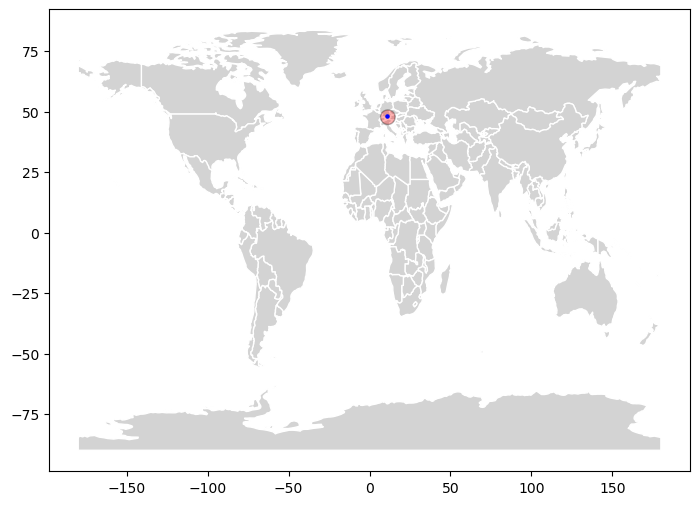

In [2]:
from shapely.geometry import Point
import geopandas as gpd


# Create point and buffer
center = Point(11.0, 48.0)  # lon, lat
gdf = gpd.GeoDataFrame(geometry=[center], crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)  # project to meters
buffer = gdf.buffer(500_000)  # 500 km in meters
buffer_gdf = gpd.GeoDataFrame(geometry=buffer).to_crs(epsg=4326)

# Load world map from URL (Natural Earth shapefile as GeoJSON)
world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")

# Plot
ax = world.plot(figsize=(10, 6), color='lightgrey', edgecolor='white')
buffer_gdf.plot(ax=ax, color='red', alpha=0.3, edgecolor='k')
gdf.to_crs(epsg=4326).plot(ax=ax, color='blue', markersize=5)

Running the spacial/temporal KNN imputation for RF or other methods...

In [104]:
# List of columns you want to impute
cols_to_impute = [
    'N.rate..kg.N.ha.1.',
    'Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha)',
    'Agricultural_Use_–_Insecticides_(t)',
    'Agricultural_Use_–_Herbicides_(t)',
    'Agricultural_Use_–_Fungicides_and_Bactericides_(t)',
    'Agricultural_Use_–_Pesticides_(total)_(t)',
    'Wheat.Type'
]

# Copy the cleaned dataframe to avoid modifying original
df_imputed = df_cleaned.copy()

# Loop through each column and apply the spatial-temporal imputation
for col in cols_to_impute:
    print(f"Imputing column: {col}")
    df_imputed = spatial_temporal_knn_impute(
        df=df_imputed,
        value_col=col,
        lat_col='Conversion.for.latitude',
        lon_col='Conversion.for.longitude',
        time_col='year',
        k=2,
        time_weight=0.5,
        max_time_diff=3,
        max_spatial_radius_km=10000  
    )



Imputing column: N.rate..kg.N.ha.1.
Imputing column: Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha)
Imputing column: Agricultural_Use_–_Insecticides_(t)
Imputing column: Agricultural_Use_–_Herbicides_(t)
Imputing column: Agricultural_Use_–_Fungicides_and_Bactericides_(t)
Imputing column: Agricultural_Use_–_Pesticides_(total)_(t)
Imputing column: Wheat.Type


In [120]:
summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| start_date                                            | int64   |   69430 |          100   |          7 |
| AEZ                                                   | float64 |   69430 |          100   |         31 |
| Data.ID                                               | object  |   69430 |          100   |         51 |
| temp1                                                 | float64 |   69430 |          100   |        268 |
| temp2                                                 | float64 |   69430 |          100   |        270 |
| temp3                                                 | float64 |   69430 |          100   |        275 |
| temp4                     

In [19]:
df_imputed.to_csv("../../../data/finaldatasets/testdata/imputeddata.csv", index=False)